<h1> Step 2 – Random Forests </h1>

In [73]:
# usual imports in a classic ML pipeline for Classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics, svm

# we can import the random forest algorithms from 
# scikit-learn's ensemble -features
from sklearn.ensemble import RandomForestClassifier

# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# let's add some helpful features like the pipelines
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.calibration import CalibratedClassifierCV

<h3> Data set link </h3>
<a href="https://www.kaggle.com/datasets/sumedh1507/asthma-dataset">Asthma Risk & Severity Dataset</a>


In [74]:
# load the data
df = pd.read_csv("synthetic_asthma_dataset.csv")


# let's quickly see the first 5 rows of data
df

,Patient_ID,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level
0,ASTH100000,52,Female,27.6,Former,1,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0,NaN
1,ASTH100001,15,Male,24.6,Former,0,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0,NaN
2,ASTH100002,72,Female,17.6,Never,0,NaN,Moderate,Moderate,Indoor,NaN,0.38,0,303.3,15.3,0,NaN
3,ASTH100003,61,Male,16.8,Never,0,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1,Poorly Controlled
4,ASTH100004,21,Male,30.2,Never,0,NaN,Moderate,Active,Indoor,NaN,0.82,3,535.0,27.7,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ASTH109995,70,Male,25.0,Never,0,NaN,Low,Sedentary,Indoor,NaN,0.67,0,580.6,18.7,0,NaN
9996,ASTH109996,78,Female,24.8,Never,0,Pollen,Low,Moderate,Indoor,Diabetes,0.72,1,417.6,40.8,0,NaN
9997,ASTH109997,58,Male,30.1,Former,1,Pollen,Low,Moderate,Indoor,NaN,0.28,0,459.1,20.3,1,Not Controlled
9998,ASTH109998,88,Female,31.2,Former,0,Pollen,Moderate,Moderate,Indoor,NaN,0.44,0,415.9,25.0,0,NaN


In [75]:
# Check value counts for Has_Asthma:
df['Has_Asthma'].value_counts()

Has_Asthma
0    7567
1    2433
Name: count, dtype: int64

In [76]:
# Check total no of records
df.shape

(10000, 17)

In [77]:
# drop Patient_ID field since it is not required
df.drop(columns=['Patient_ID'], inplace=True)
df.head()

,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level
0,52,Female,27.6,Former,1,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0,NaN
1,15,Male,24.6,Former,0,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0,NaN
2,72,Female,17.6,Never,0,NaN,Moderate,Moderate,Indoor,NaN,0.38,0,303.3,15.3,0,NaN
3,61,Male,16.8,Never,0,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1,Poorly Controlled
4,21,Male,30.2,Never,0,NaN,Moderate,Active,Indoor,NaN,0.82,3,535.0,27.7,0,NaN


In [78]:
# check duplicates and missing values
df.duplicated().sum()

np.int64(0)

In [79]:
# do we have missing values? apparently not
# dataset can't have any missing values when passing the data
# to the machine learning algorithm
df.isna().sum()

Age                           0
Gender                        0
BMI                           0
Smoking_Status                0
Family_History                0
Allergies                  2936
Air_Pollution_Level           0
Physical_Activity_Level       0
Occupation_Type               0
Comorbidities              4967
Medication_Adherence          0
Number_of_ER_Visits           0
Peak_Expiratory_Flow          0
FeNO_Level                    0
Has_Asthma                    0
Asthma_Control_Level       7567
dtype: int64

In [80]:
# Drop the columns Comorbidities, Asthma_Control_Level
df = df.drop(columns=['Comorbidities', 'Asthma_Control_Level'])
df.isna().sum()

Age                           0
Gender                        0
BMI                           0
Smoking_Status                0
Family_History                0
Allergies                  2936
Air_Pollution_Level           0
Physical_Activity_Level       0
Occupation_Type               0
Medication_Adherence          0
Number_of_ER_Visits           0
Peak_Expiratory_Flow          0
FeNO_Level                    0
Has_Asthma                    0
dtype: int64

In [81]:
# Check value counts for Allergies:
df['Allergies'].value_counts()


Allergies
Dust        2479
Pollen      1999
Pets        1585
Multiple    1001
Name: count, dtype: int64

In [82]:
# Example: replace NaN with None in Allergies
df['Allergies'] = df['Allergies'].fillna("None")


In [83]:
# Check for missing values again
df.isna().sum()

Age                        0
Gender                     0
BMI                        0
Smoking_Status             0
Family_History             0
Allergies                  0
Air_Pollution_Level        0
Physical_Activity_Level    0
Occupation_Type            0
Medication_Adherence       0
Number_of_ER_Visits        0
Peak_Expiratory_Flow       0
FeNO_Level                 0
Has_Asthma                 0
dtype: int64

In [84]:
# Check value counts for Allergies:
df['Allergies'].value_counts()

Allergies
None        2936
Dust        2479
Pollen      1999
Pets        1585
Multiple    1001
Name: count, dtype: int64

In [85]:
# converts Allergies into binary since it is a nominal category

from sklearn.preprocessing import OneHotEncoder
variables = ['Allergies']
# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)
df.head()

,Age,Gender,BMI,Smoking_Status,Family_History,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Allergies_Dust,Allergies_Multiple,Allergies_None,Allergies_Pets,Allergies_Pollen
0,52,Female,27.6,Former,1,Moderate,Sedentary,Outdoor,0.38,0,421.0,46.0,0,0,0,1,0,0
1,15,Male,24.6,Former,0,Low,Moderate,Indoor,0.60,2,297.6,22.9,0,1,0,0,0,0
2,72,Female,17.6,Never,0,Moderate,Moderate,Indoor,0.38,0,303.3,15.3,0,0,0,1,0,0
3,61,Male,16.8,Never,0,High,Sedentary,Outdoor,0.60,1,438.0,40.1,1,0,1,0,0,0
4,21,Male,30.2,Never,0,Moderate,Active,Indoor,0.82,3,535.0,27.7,0,0,0,1,0,0


In [86]:
df.head()

,Age,Gender,BMI,Smoking_Status,Family_History,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Allergies_Dust,Allergies_Multiple,Allergies_None,Allergies_Pets,Allergies_Pollen
0,52,Female,27.6,Former,1,Moderate,Sedentary,Outdoor,0.38,0,421.0,46.0,0,0,0,1,0,0
1,15,Male,24.6,Former,0,Low,Moderate,Indoor,0.60,2,297.6,22.9,0,1,0,0,0,0
2,72,Female,17.6,Never,0,Moderate,Moderate,Indoor,0.38,0,303.3,15.3,0,0,0,1,0,0
3,61,Male,16.8,Never,0,High,Sedentary,Outdoor,0.60,1,438.0,40.1,1,0,1,0,0,0
4,21,Male,30.2,Never,0,Moderate,Active,Indoor,0.82,3,535.0,27.7,0,0,0,1,0,0


In [87]:
df.shape

(10000, 18)

In [88]:
# Check value counts for Gender:
df['Gender'].value_counts()

Gender
Female    4814
Male      4786
Other      400
Name: count, dtype: int64

In [89]:
# converts Gender into binary since it is a nominal category
variables 
from sklearn.preprocessing import OneHotEncoder
variables = ['Gender']
# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)
df.head()

,Age,BMI,Smoking_Status,Family_History,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Allergies_Dust,Allergies_Multiple,Allergies_None,Allergies_Pets,Allergies_Pollen,Gender_Female,Gender_Male,Gender_Other
0,52,27.6,Former,1,Moderate,Sedentary,Outdoor,0.38,0,421.0,46.0,0,0,0,1,0,0,1,0,0
1,15,24.6,Former,0,Low,Moderate,Indoor,0.60,2,297.6,22.9,0,1,0,0,0,0,0,1,0
2,72,17.6,Never,0,Moderate,Moderate,Indoor,0.38,0,303.3,15.3,0,0,0,1,0,0,1,0,0
3,61,16.8,Never,0,High,Sedentary,Outdoor,0.60,1,438.0,40.1,1,0,1,0,0,0,0,1,0
4,21,30.2,Never,0,Moderate,Active,Indoor,0.82,3,535.0,27.7,0,0,0,1,0,0,0,1,0


In [90]:
# Check value counts for Smoking_Status:
df['Smoking_Status'].value_counts()

Smoking_Status
Never      6070
Former     2487
Current    1443
Name: count, dtype: int64

In [91]:
# Map Smoking_Status - Ordinal categories
category_mapper = {
    'Current': 2,
    'Former': 1,
    'Never': 0
}

df['Smoking_Status'] = df['Smoking_Status'].replace(category_mapper)
df.head()

,Age,BMI,Smoking_Status,Family_History,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Allergies_Dust,Allergies_Multiple,Allergies_None,Allergies_Pets,Allergies_Pollen,Gender_Female,Gender_Male,Gender_Other
0,52,27.6,1,1,Moderate,Sedentary,Outdoor,0.38,0,421.0,46.0,0,0,0,1,0,0,1,0,0
1,15,24.6,1,0,Low,Moderate,Indoor,0.60,2,297.6,22.9,0,1,0,0,0,0,0,1,0
2,72,17.6,0,0,Moderate,Moderate,Indoor,0.38,0,303.3,15.3,0,0,0,1,0,0,1,0,0
3,61,16.8,0,0,High,Sedentary,Outdoor,0.60,1,438.0,40.1,1,0,1,0,0,0,0,1,0
4,21,30.2,0,0,Moderate,Active,Indoor,0.82,3,535.0,27.7,0,0,0,1,0,0,0,1,0


In [92]:
# Check value counts for Air_Pollution_Level:
df['Air_Pollution_Level'].value_counts()

Air_Pollution_Level
Moderate    4915
Low         2984
High        2101
Name: count, dtype: int64

In [93]:
# Map Air_Pollution_Level- Ordinal categories
category_mapper = {
    'High': 2,
    'Moderate': 1,
    'Low': 0
}

df['Air_Pollution_Level'] = df['Air_Pollution_Level'].replace(category_mapper)
df.head()

,Age,BMI,Smoking_Status,Family_History,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Allergies_Dust,Allergies_Multiple,Allergies_None,Allergies_Pets,Allergies_Pollen,Gender_Female,Gender_Male,Gender_Other
0,52,27.6,1,1,1,Sedentary,Outdoor,0.38,0,421.0,46.0,0,0,0,1,0,0,1,0,0
1,15,24.6,1,0,0,Moderate,Indoor,0.60,2,297.6,22.9,0,1,0,0,0,0,0,1,0
2,72,17.6,0,0,1,Moderate,Indoor,0.38,0,303.3,15.3,0,0,0,1,0,0,1,0,0
3,61,16.8,0,0,2,Sedentary,Outdoor,0.60,1,438.0,40.1,1,0,1,0,0,0,0,1,0
4,21,30.2,0,0,1,Active,Indoor,0.82,3,535.0,27.7,0,0,0,1,0,0,0,1,0


In [94]:
# Check value counts for Physical_Activity_Level:
df['Physical_Activity_Level'].value_counts()

Physical_Activity_Level
Sedentary    4062
Moderate     3909
Active       2029
Name: count, dtype: int64

In [95]:
# Map Physical_Activity_Level- Ordinal categories
category_mapper = {
    'Active': 2,
    'Moderate': 1,
    'Sedentary': 0
}

df['Physical_Activity_Level'] = df['Physical_Activity_Level'].replace(category_mapper)
df.head()

,Age,BMI,Smoking_Status,Family_History,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Allergies_Dust,Allergies_Multiple,Allergies_None,Allergies_Pets,Allergies_Pollen,Gender_Female,Gender_Male,Gender_Other
0,52,27.6,1,1,1,0,Outdoor,0.38,0,421.0,46.0,0,0,0,1,0,0,1,0,0
1,15,24.6,1,0,0,1,Indoor,0.60,2,297.6,22.9,0,1,0,0,0,0,0,1,0
2,72,17.6,0,0,1,1,Indoor,0.38,0,303.3,15.3,0,0,0,1,0,0,1,0,0
3,61,16.8,0,0,2,0,Outdoor,0.60,1,438.0,40.1,1,0,1,0,0,0,0,1,0
4,21,30.2,0,0,1,2,Indoor,0.82,3,535.0,27.7,0,0,0,1,0,0,0,1,0


In [96]:
# Check value counts for Occupation_Type:
df['Occupation_Type'].value_counts()

Occupation_Type
Indoor     7035
Outdoor    2965
Name: count, dtype: int64

In [97]:
from sklearn.preprocessing import LabelEncoder

# list all variables that can be binary-converted
variables = ['Occupation_Type']

# load the encoder
encoder = LabelEncoder()

# convert the listed variables
df[variables] = df[variables].apply(encoder.fit_transform)

df.head()

,Age,BMI,Smoking_Status,Family_History,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Allergies_Dust,Allergies_Multiple,Allergies_None,Allergies_Pets,Allergies_Pollen,Gender_Female,Gender_Male,Gender_Other
0,52,27.6,1,1,1,0,1,0.38,0,421.0,46.0,0,0,0,1,0,0,1,0,0
1,15,24.6,1,0,0,1,0,0.60,2,297.6,22.9,0,1,0,0,0,0,0,1,0
2,72,17.6,0,0,1,1,0,0.38,0,303.3,15.3,0,0,0,1,0,0,1,0,0
3,61,16.8,0,0,2,0,1,0.60,1,438.0,40.1,1,0,1,0,0,0,0,1,0
4,21,30.2,0,0,1,2,0,0.82,3,535.0,27.7,0,0,0,1,0,0,0,1,0


<h3>There's no ordinal or nominal categories here, we can proceed to X/y -phase</h3>

In [98]:
df.head()

,Age,BMI,Smoking_Status,Family_History,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Allergies_Dust,Allergies_Multiple,Allergies_None,Allergies_Pets,Allergies_Pollen,Gender_Female,Gender_Male,Gender_Other
0,52,27.6,1,1,1,0,1,0.38,0,421.0,46.0,0,0,0,1,0,0,1,0,0
1,15,24.6,1,0,0,1,0,0.60,2,297.6,22.9,0,1,0,0,0,0,0,1,0
2,72,17.6,0,0,1,1,0,0.38,0,303.3,15.3,0,0,0,1,0,0,1,0,0
3,61,16.8,0,0,2,0,1,0.60,1,438.0,40.1,1,0,1,0,0,0,0,1,0
4,21,30.2,0,0,1,2,0,0.82,3,535.0,27.7,0,0,0,1,0,0,0,1,0


<h3>X/y and train/test -splits</h3>

In [99]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("Has_Asthma", axis=1)

# our target variable is y
y = df['Has_Asthma']

In [100]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

Train the logistic regression model

In [101]:
# create the model and train it with the data
# model = LogisticRegression()
# use probability=True for easier metrics

# if you wish to use LinearSVC => we need to wrap it into a
# CalibratedClassifierCV so it outputs probabilities for the metrics
# model = make_pipeline(StandardScaler(), CalibratedClassifierCV(svm.LinearSVC()))

# Pipeline is super helpful here, since we can integrate the scaler
# before the model, no need to manually scale anything
model = make_pipeline(StandardScaler(), RandomForestClassifier())
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


Classification error metrics

In [102]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

In [103]:
# print the classification report based on true values and predictions
print(classification_report(y_test, predictions))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1890
           1       1.00      0.99      1.00       610

    accuracy                           1.00      2500
   macro avg       1.00      1.00      1.00      2500
weighted avg       1.00      1.00      1.00      2500


Model overall accuracy: 99.76%


<Axes: >

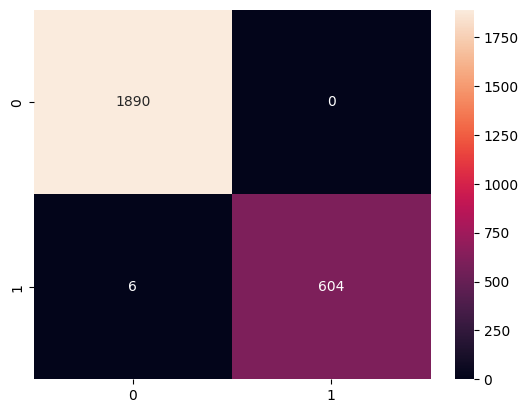

In [104]:
# see the confusion matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g')

In [ ]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary logistic regression, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multinomial logistic regression , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# basically 0.5 means you could get the same result with just random guessing
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

0.9999973978662504

Using the model in practice

In [106]:
df.columns

Index(['Age', 'BMI', 'Smoking_Status', 'Family_History', 'Air_Pollution_Level',
       'Physical_Activity_Level', 'Occupation_Type', 'Medication_Adherence',
       'Number_of_ER_Visits', 'Peak_Expiratory_Flow', 'FeNO_Level',
       'Has_Asthma', 'Allergies_Dust', 'Allergies_Multiple', 'Allergies_None',
       'Allergies_Pets', 'Allergies_Pollen', 'Gender_Female', 'Gender_Male',
       'Gender_Other'],
      dtype='str')

In [107]:
import pandas as pd

# Single test row (features only, without target)
tester_row = {
    'Age': 67.0,
    'BMI': 36.6,
    'Smoking_Status': 0,             # map according to your encoding                   # 0 = Male, 1 = Female, 2 = Other
    'Family_History': 1,             # 0 = No, 1 = Yes
    'Air_Pollution_Level': 1, # map or keep as text
    'Physical_Activity_Level': 1,    # 0 = Sedentary, 1 = Moderate, 2 = Active
    'Occupation_Type': 1,     # map/one-hot encode if needed
    'Medication_Adherence': 0.8,
    'Number_of_ER_Visits': 2,
    'Peak_Expiratory_Flow': 421.0,
    'FeNO_Level': 46.0,

    # One-hot encoded Allergies
    'Allergies_Dust': 0,
    'Allergies_Multiple': 0,
    'Allergies_None': 0,
    'Allergies_Pets': 0,
    'Allergies_Pollen': 1,

    'Gender_Female' : 1,
    'Gender_Male' : 0,
    'Gender_Other' : 0,
}

tester_row = pd.DataFrame([tester_row])

In [ ]:
print("All probabilities by category:")
print(model.predict_proba(tester_row))
print()

# change these based on your original data
labels = ["No", "Yes"]

print("Does this person has Asthma:")
result = labels[model.predict(tester_row)[0]]
print(result)
print("-------------------")

All probabilities by category:
[[0.22 0.78]]

DDoes this person has Asthma:
Yes
-------------------


In [109]:
df.corr()

,Age,BMI,Smoking_Status,Family_History,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Allergies_Dust,Allergies_Multiple,Allergies_None,Allergies_Pets,Allergies_Pollen,Gender_Female,Gender_Male,Gender_Other
Age,1.000000,-0.010078,0.008895,0.007481,-0.013675,0.009468,0.006354,-0.005332,-0.014775,0.012447,0.012180,-0.004346,0.003998,0.012266,-0.001366,-0.002137,-0.010015,0.009156,-0.006316,-0.007247
BMI,-0.010078,1.000000,-0.018827,-0.001244,-0.000511,-0.021542,-0.009370,-0.001318,0.003024,-0.000559,-0.005137,0.098425,-0.007349,0.006161,0.003129,0.011650,-0.010890,0.003183,0.002132,-0.013551
Smoking_Status,0.008895,-0.018827,1.000000,-0.011031,-0.004929,0.016718,-0.013770,0.028093,0.000611,-0.000240,0.018626,0.246034,-0.012628,0.010529,-0.001951,0.010976,-0.002068,0.015411,-0.012978,-0.006211
Family_History,0.007481,-0.001244,-0.011031,1.000000,-0.000337,0.007163,0.007344,0.019463,0.020411,-0.009463,0.005389,0.409531,-0.008125,-0.007757,0.012522,0.002449,-0.001902,-0.006342,0.006500,-0.000400
Air_Pollution_Level,-0.013675,-0.000511,-0.004929,-0.000337,1.000000,-0.010412,0.015413,-0.003965,-0.001518,-0.008268,-0.000756,0.299996,0.023858,0.000654,0.002870,-0.024396,-0.007240,-0.002524,-0.000395,0.007443
Physical_Activity_Level,0.009468,-0.021542,0.016718,0.007163,-0.010412,1.000000,0.013014,-0.002468,0.015908,-0.003279,-0.006458,-0.265186,0.010751,0.004202,-0.011980,-0.013725,0.011414,-0.001677,-0.000533,0.005635
Occupation_Type,0.006354,-0.009370,-0.013770,0.007344,0.015413,0.013014,1.000000,0.018531,-0.005180,0.014650,0.005841,-0.010912,-0.005590,-0.003499,0.011768,-0.005367,0.000162,-0.002345,0.005677,-0.008492
Medication_Adherence,-0.005332,-0.001318,0.028093,0.019463,-0.003965,-0.002468,0.018531,1.000000,-0.001243,-0.012747,0.019040,0.003785,0.002053,-0.013393,0.015695,-0.008839,-0.001967,0.004619,0.000545,-0.013165
Number_of_ER_Visits,-0.014775,0.003024,0.000611,0.020411,-0.001518,0.015908,-0.005180,-0.001243,1.000000,0.001293,0.009969,0.005781,0.002402,-0.013032,0.008030,0.009069,-0.010238,0.005777,-0.005315,-0.001180
Peak_Expiratory_Flow,0.012447,-0.000559,-0.000240,-0.009463,-0.008268,-0.003279,0.014650,-0.012747,0.001293,1.000000,0.000575,-0.005207,0.009419,-0.016133,0.003786,-0.000690,-0.001743,0.012359,-0.007989,-0.011148


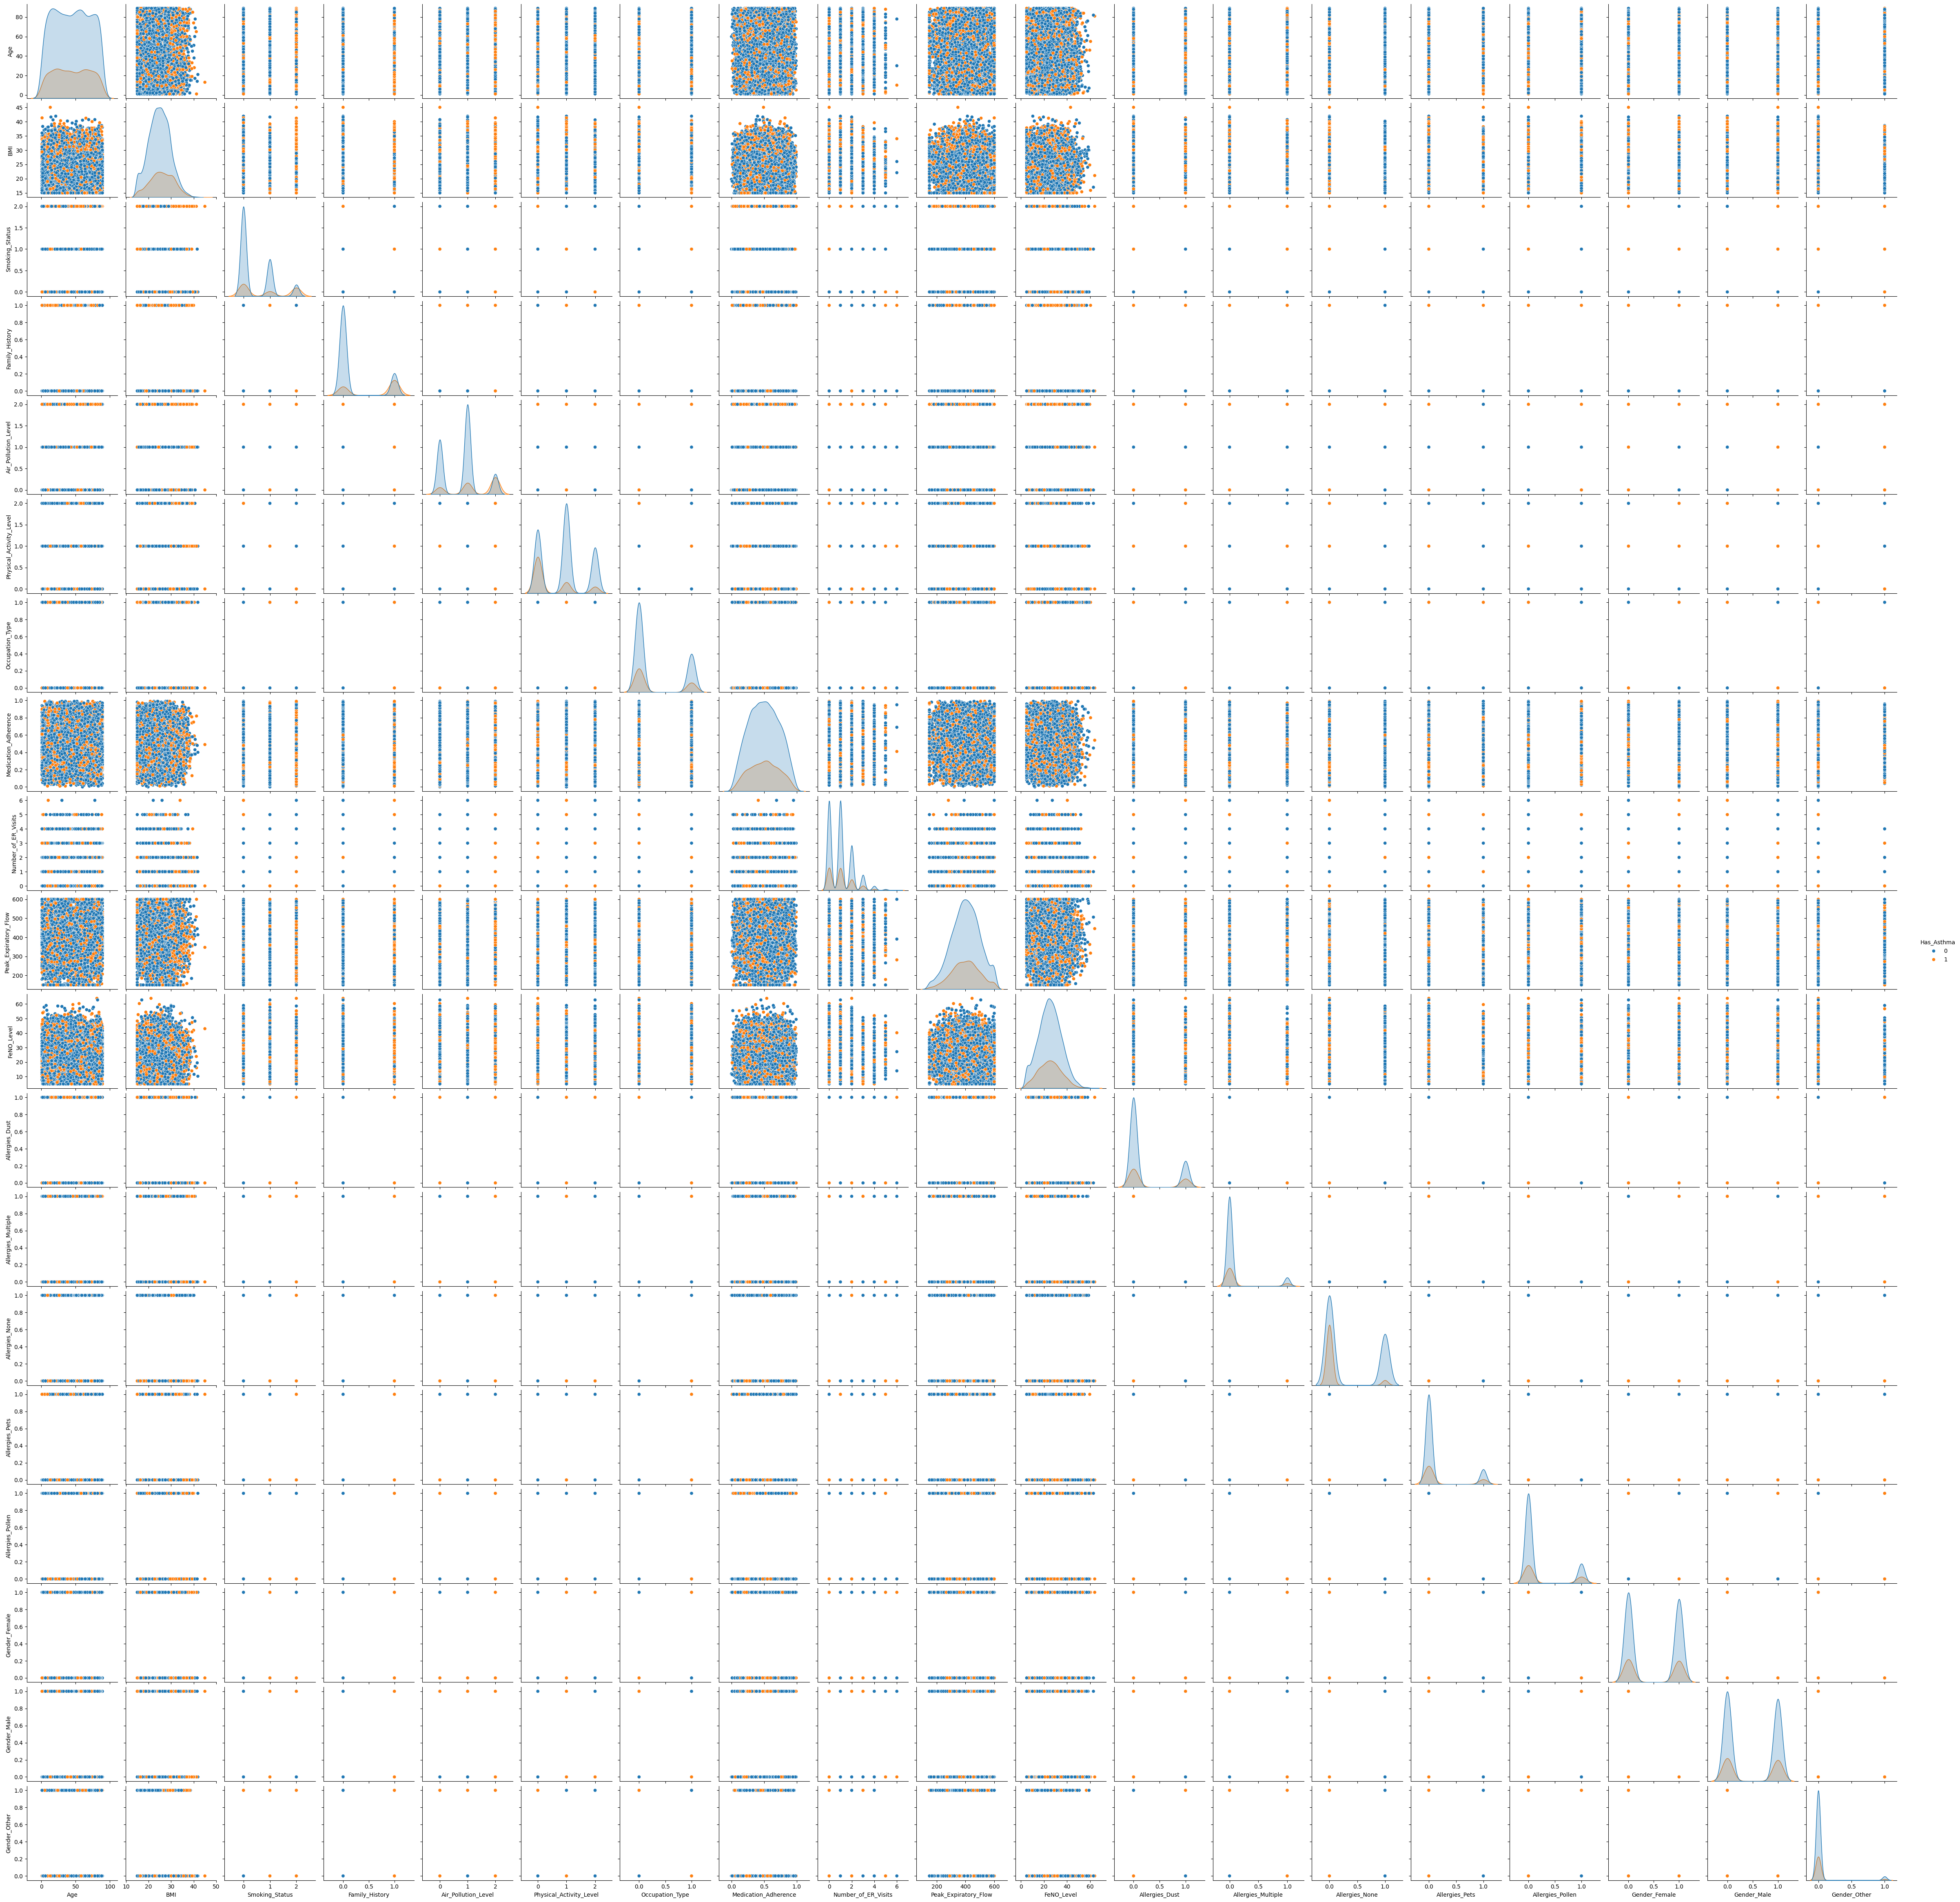

In [110]:
sns.pairplot(df, hue='Has_Asthma')

<h1 style="color: green;">Comparisons</h1>



<table>
  <tr>
    <th>Model</th>
    <th>Accuracy</th>
    <th>ROC AUC</th>
    <th>Probability for Asthma</th>
    <th>Prediction</th>
  </tr>
  <tr>
    <td>Logistic Regression</td>
    <td>91.57%</td>
    <td>0.965</td>
    <td>0.86</td>
    <td><strong>Yes</strong></td>
  </tr>
  <tr>
    <td>SVC</td>
    <td>98.48%</td>
    <td>0.999</td>
    <td>0.994</td>
    <td><strong>Yes</strong></td>
  </tr>
  <tr>
    <td>Random Forest</td>
    <td>99.76%</td>
    <td>0.9999</td>
    <td>0.78</td>
    <td><strong>Yes</strong></td>
  </tr>
</table>

<h2>Summary</h2>

<p><strong>Logistic Regression:</strong><br>
Accuracy is at 91.57%. ROC AUC of 0.965 shows good ability to distinguish between asthma and non-asthma. Probability for asthma is 0.86. This can miss some people who actually have asthma, because it only correctly identifies ~81% of them</p>

<p><strong>SVC:</strong><br>
High accuracy at 98.48% and perfect ROC AUC of 0.999 indicate excellent performance. Probability for asthma is 0.994, shows very high confidence. Very reliable for identifying asthma cases, with few false negatives.</p>

<p><strong>Random Forest:</strong><br>
Extremely high accuracy at 99.76% and almost perfect ROC AUC (~1.0). Probability for asthma is 0.78</p>

Finally,
- Logistic Regression is good but slightly less reliable than the others.<br>
- SVC provides very confident predictions with excellent accuracy.<br>
- Random Forest is almost perfect and the most reliable for this dataset.<br>

